In [24]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
data = pd.read_csv('house_train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [26]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [27]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [28]:
X = data[['FireplaceQu', 'GarageQual']]
y = data['SalePrice']

In [29]:
print(data.columns)

Index(['FireplaceQu', 'GarageQual', 'SalePrice'], dtype='object')


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

In [34]:
X_train,X_test,y_train,y_test,train_test_split(X,y,test_size=0.2,random_state=2)

(     FireplaceQu GarageQual GarageQual_imputed
 254          NaN         TA                 TA
 1066          TA         TA                 TA
 638          NaN        NaN                NaN
 799           TA         TA                 TA
 380           Gd         TA                 TA
 ...          ...        ...                ...
 1095          Gd         TA                 TA
 1130          TA         TA                 TA
 1294         NaN         TA                 TA
 860           Gd         TA                 TA
 1126          TA         TA                 TA
 
 [1168 rows x 3 columns],
      FireplaceQu GarageQual GarageQual_imputed
 892          NaN         TA                 TA
 1105          TA         TA                 TA
 413           Gd         TA                 TA
 522           Gd         TA                 TA
 1036          Ex         TA                 TA
 ...          ...        ...                ...
 479          NaN         TA                 TA
 1361       

In [38]:
X_train['GarageQual_imputed']=X_train['GarageQual']
X_test['GarageQual_imputed']=X_test['GarageQual']

X_train['FireplaceQu_imputed']=X_train['FireplaceQu']
X_test['FireplaceQu_imputed']=X_test['FireplaceQu']


In [36]:
X_train

,FireplaceQu,GarageQual,GarageQual_imputed,FireplaceQu_imputed
254,NaN,TA,TA,NaN
1066,TA,TA,TA,TA
638,NaN,NaN,NaN,NaN
799,TA,TA,TA,TA
380,Gd,TA,TA,Gd
...,...,...,...,...
1095,Gd,TA,TA,Gd
1130,TA,TA,TA,TA
1294,NaN,TA,TA,NaN
860,Gd,TA,TA,Gd


In [39]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/var/folders/ry/wgj587lj7y5fgymw0jbl6lgm0000gn/T/ipykernel_2852/2056505658.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_tr

In [41]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() /len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts() /len(X_train)

    ],
    axis=1)

temp.columns=['origanal','imputed']

In [42]:
temp

,origanal,imputed
TA,0.951087,0.950342
Fa,0.032609,0.031678
Gd,0.011775,0.013699
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [44]:
temp = pd.concat(
    [
        X_train['FireplaceQu'].value_counts() /len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_imputed'].value_counts() /len(data)

    ],
    axis=1)

temp.columns=['origanal','imputed']

In [45]:
temp

,origanal,imputed
Gd,0.491143,0.392466
TA,0.405797,0.329452
Fa,0.043478,0.031507
Ex,0.033816,0.026027
Po,0.025765,0.020548


/var/folders/ry/wgj587lj7y5fgymw0jbl6lgm0000gn/T/ipykernel_2852/2696441575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
/var/folders/ry/wgj587lj7y5fgymw0jbl6lgm0000gn/T/ipykernel_2852/2696441575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
/var/folders/ry/wgj587

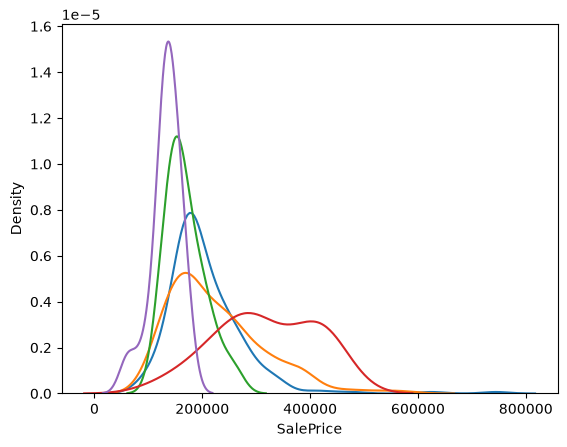

In [49]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(
        y_train[X_train['FireplaceQu'] == category],
        hist=False,
        label=category
    )

plt.show()

/var/folders/ry/wgj587lj7y5fgymw0jbl6lgm0000gn/T/ipykernel_2852/3495950589.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
/var/folders/ry/wgj587lj7y5fgymw0jbl6lgm0000gn/T/ipykernel_2852/3495950589.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
/var/folders/ry/wgj587

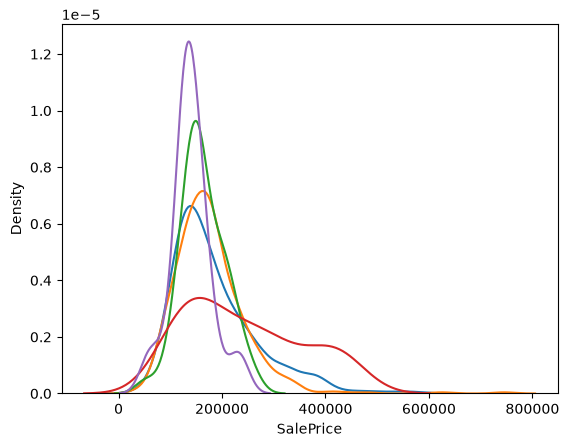

In [51]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(
        y_train[X_train['FireplaceQu_imputed'] == category],
        hist=False,
        label=category
    )

plt.show()